# 3 - AM Envelope Demod

Dieses Notebook liest ein zuvor gespeichertes AM-Signal (z. B. `AM-carrier.npy`) ein,
stellt es dar und demoduliert es per Hüllkurvendemodulation.

## Prinzip der Hüllkurvendemodulation

Ein klassischer Hüllkurvendetektor besteht aus zwei Schritten:

1. **Gleichrichtung**
   - Aus dem AM-Signal wird ein nur positiver Verlauf gewonnen (hier: Vollweggleichrichtung mit Betrag).

2. **Tiefpassfilterung**
   - Die hochfrequente Trägeranteile werden geglättet, die langsame Hüllkurve bleibt.
   - Hier verwenden wir zunächst didaktisch einfach einen **Sliding-Averager** (gleitender Mittelwert)
     mit einstellbarer Fensterbreite.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['axes.grid'] = True

In [2]:
# 1) Signal laden
sig_path = Path('AM-carrier.npy')
meta_path = Path('AM-carrier-meta.npy')

if not sig_path.exists():
    raise FileNotFoundError(f'{sig_path} nicht gefunden. Bitte zuerst Notebook 2 ausführen und speichern.')

s_am = np.load(sig_path).astype(np.float64)

meta = {}
if meta_path.exists():
    meta = np.load(meta_path, allow_pickle=True).item()

# Für die Zeitachse / Demodulation: fs aus Meta, sonst 48 kHz als Fallback
fs = float(meta.get('fs_hz', 48_000.0))
t = np.arange(len(s_am)) / fs

print(f'Geladen: {sig_path} ({len(s_am)} Samples), fs = {fs:.1f} Hz')
if meta:
    print('Meta gefunden:', meta)

Geladen: AM-carrier.npy (200000 Samples), fs = 200000.0 Hz
Meta gefunden: {'fs_hz': 200000.0, 'f_c_hz': 20000.0, 'f_m_hz': 200.0, 'm': 0.6, 'DC': 1.0, 'U_c': 1.0, 'wave_type': 'cosinus', 'N_sig': 200000}


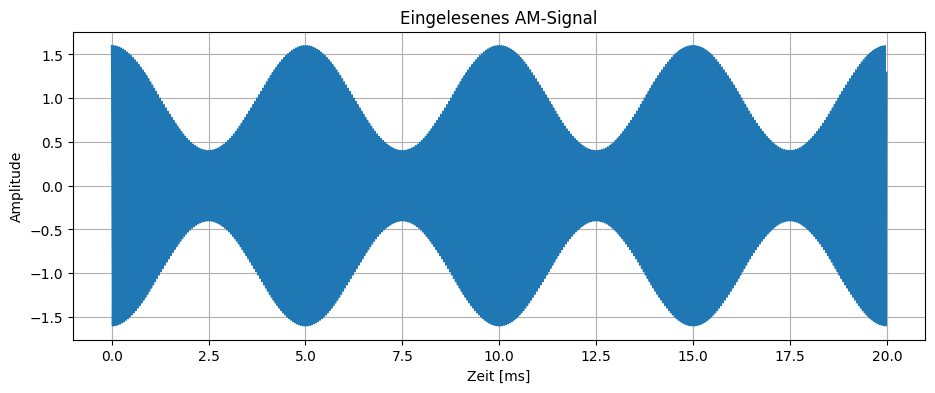

In [3]:
# Plot: Eingelesenes AM-Signal
t_plot_ms = 20.0
n_plot = min(len(s_am), int(t_plot_ms * 1e-3 * fs))

plt.figure()
plt.plot(t[:n_plot] * 1e3, s_am[:n_plot], lw=1.2)
plt.title('Eingelesenes AM-Signal')
plt.xlabel('Zeit [ms]')
plt.ylabel('Amplitude')
plt.show()

In [4]:
# 2) Hüllkurvendemodulation: Gleichrichtung + Sliding-Averager-Tiefpass

# Gleichrichtung (Vollwelle)
x_rect = np.abs(s_am)

# Tiefpass via gleitendem Mittelwert
# Konfigurationsparameter:
f_lp = 1000.0  # "Fensterbreite" über äquivalente Grenzfrequenz [Hz]

# Einfache Zuordnung: Fensterbreite in Samples ~ fs/f_lp
N_win = max(3, int(round(fs / max(1.0, f_lp))))
if N_win % 2 == 0:
    N_win += 1

h = np.ones(N_win, dtype=np.float64) / N_win
x_env = np.convolve(x_rect, h, mode='same')

# Optional: DC-Anteil entfernen für hörbares Audiosignal
x_demod = x_env - np.mean(x_env)

print(f'Sliding-Averager: N_win = {N_win} Samples (f_lp ~ {f_lp:.1f} Hz)')

Sliding-Averager: N_win = 201 Samples (f_lp ~ 1000.0 Hz)


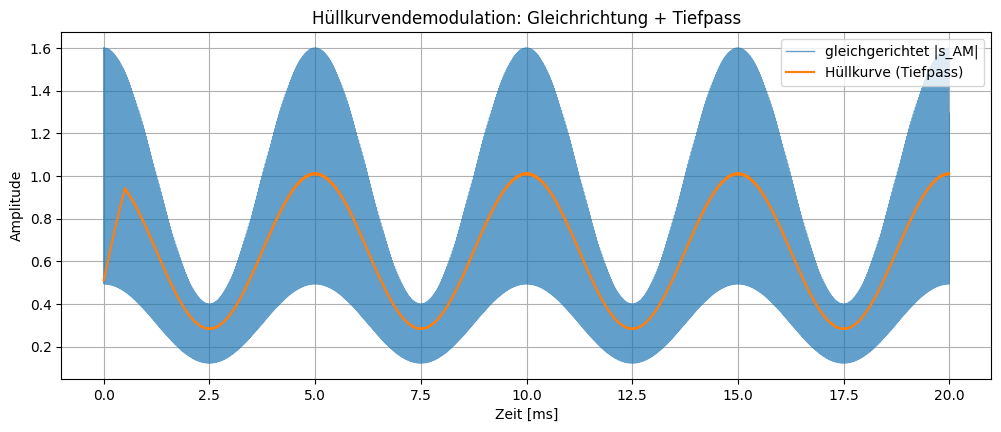

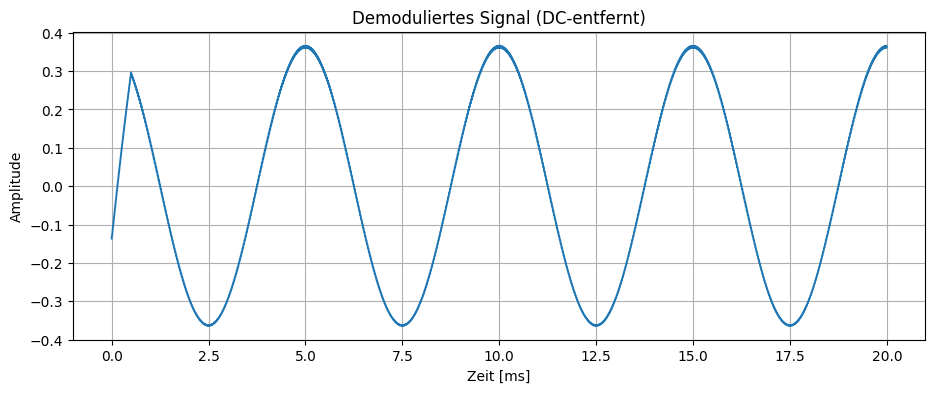

In [5]:
# Plot: Gleichgerichtet und demoduliert
plt.figure(figsize=(12, 4.5))
plt.plot(t[:n_plot] * 1e3, x_rect[:n_plot], label='gleichgerichtet |s_AM|', lw=1.0, alpha=0.7)
plt.plot(t[:n_plot] * 1e3, x_env[:n_plot], label='Hüllkurve (Tiefpass)', lw=1.6)
plt.title('Hüllkurvendemodulation: Gleichrichtung + Tiefpass')
plt.xlabel('Zeit [ms]')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

plt.figure()
plt.plot(t[:n_plot] * 1e3, x_demod[:n_plot], lw=1.4)
plt.title('Demoduliertes Signal (DC-entfernt)')
plt.xlabel('Zeit [ms]')
plt.ylabel('Amplitude')
plt.show()

## Audioausgabe im Notebook

Ja, Audioausgabe ist im Python-Notebook möglich.

- Primär hier über `IPython.display.Audio` (inline im Notebook).
- Optional auch über `sounddevice` (falls lokales Audio-Backend verfügbar ist).

Für bessere Hörbarkeit wird das demodulierte Signal zyklisch wiederholt und auf **48 kS/s** ausgegeben.

In [6]:
# 3) Audio vorbereiten und inline abspielen (48 kS/s)
from IPython.display import Audio, display

fs_audio = 48_000
duration_s = 4.0  # gewünschte Hördauer

# Wenn fs != 48 kHz: einfache lineare Resampling-Interpolation
if abs(fs - fs_audio) > 1e-9:
    t_src = np.arange(len(x_demod)) / fs
    n_dst = int(round(len(x_demod) * fs_audio / fs))
    t_dst = np.arange(n_dst) / fs_audio
    x_audio_base = np.interp(t_dst, t_src, x_demod)
else:
    x_audio_base = x_demod.copy()

# Zyklisch wiederholen
n_target = int(duration_s * fs_audio)
n_rep = int(np.ceil(n_target / max(1, len(x_audio_base))))
x_audio = np.tile(x_audio_base, n_rep)[:n_target]

# Normieren
x_audio = x_audio / max(1e-12, np.max(np.abs(x_audio)))

print(f'Audio vorbereitet: {len(x_audio)} Samples @ {fs_audio} Hz, Dauer {len(x_audio)/fs_audio:.2f} s')
display(Audio(x_audio, rate=fs_audio))

Audio vorbereitet: 192000 Samples @ 48000 Hz, Dauer 4.00 s


In [7]:
# Optional: direkte Soundausgabe mit sounddevice
use_sounddevice = False

if use_sounddevice:
    import sounddevice as sd
    sd.play(x_audio.astype(np.float32), fs_audio)
    sd.wait()
    print('Wiedergabe beendet.')
